# **Komparasi Metode Penanganan Data Imbalance terhadap Performa Decision Tree, Random Forest, dan XGBoost dalam Prediksi Customer Churn E-Commerce**


# **A Comparison of Methods for Handling Data Imbalance on the Performance of Decision Trees, Random Forests, and XGBoost in Predicting E-Commerce Customer Churn**



# 📦 SECTION 1 — Requirements & Imports

In [ ]:
#!pip install xlrd
#!pip install openpyxl


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub
import shutil
import os
import warnings
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

%matplotlib inline
sns.set_style('whitegrid')

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from scipy.stats import wilcoxon
from itertools import combinations

# 📂 SECTION 2 — Load Dataset

In [ ]:
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
print("Path to dataset files:", path)
source_path = path

Using Colab cache for faster access to the 'ecommerce-customer-churn-analysis-and-prediction' dataset.
Path to dataset files: /kaggle/input/ecommerce-customer-churn-analysis-and-prediction


In [ ]:
if IN_COLAB:
    destination_path = "/content/drive/MyDrive/ecommerce-customer-churn"
    try:
        drive.flush_and_unmount()
    except ValueError:
        pass
    drive.mount('/content/drive', force_remount=True)

    if not os.path.exists(destination_path):
        try:
            shutil.copytree(path, destination_path)
            print("Dataset copied to Drive")
        except FileNotFoundError:
            print(f"Source path '{path}' does not exist.")
    else:
        print(f"Directory {destination_path} already exists. Skipping copy.")

    dataset_path = "/content/drive/MyDrive/ecommerce-customer-churn/E Commerce Dataset.xlsx"
else:
    dataset_path = os.path.join(path, "E Commerce Dataset.xlsx")

df = pd.read_excel(dataset_path, sheet_name='E Comm')
df.head()


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Directory /content/drive/MyDrive/ecommerce-customer-churn already exists. Skipping copy.


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# 🔍 SECTION 3 — Exploratory Data Analysis (EDA)

Sub-sections:
1. Data Overview
2. Separate Categorical & Numerical Columns
3. Target Distribution (Class Imbalance)
4. Categorical Feature Distribution
5. Numerical Feature Distribution
6. Bivariate Analysis — Relationship with Churn
7. Correlation Heatmap


In [ ]:
#  1. DATA OVERVIEW
print("=" * 50)
print("Shape Dataset:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print()
print("Missing Values per Column:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print()
print("Percentage of Missing Values per Column:")
print((missing_values / len(df) * 100).round(2))
print()
print("Data Types:")
print(df.dtypes)

Shape Dataset: (5630, 20)
Duplicate Rows: 0

Missing Values per Column:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

Percentage of Missing Values per Column:
Tenure                         4.69
WarehouseToHome                4.46
HourSpendOnApp                 4.53
OrderAmountHikeFromlastYear    4.71
CouponUsed                     4.55
OrderCount                     4.58
DaySinceLastOrder              5.45
dtype: float64

Data Types:
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float

In [ ]:
# 2. SEPARATE CATEGORICAL & NUMERICAL
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

print("Categorical Columns:", cat_cols)
print("Numerical Columns  :", num_cols)


Categorical Columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Numerical Columns  : ['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


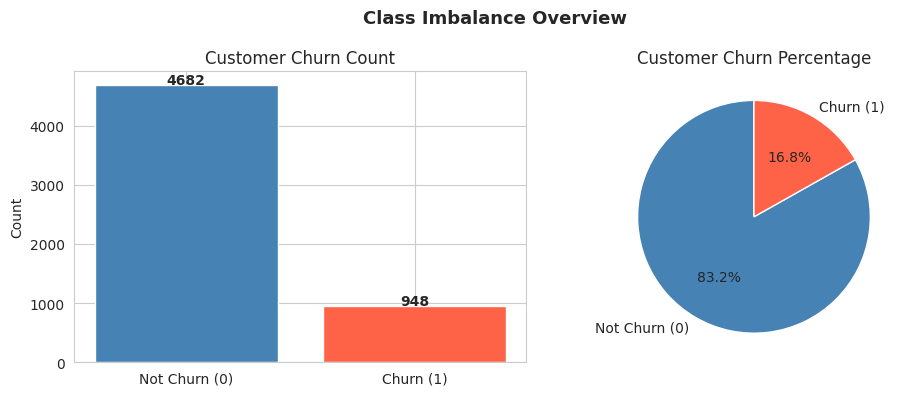


Not Churn (0): 4682 (83.2%)
Churn     (1): 948 (16.8%)
Imbalance Ratio: 1 : 4.94


In [ ]:
# 3. TARGET DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

axes[0].bar(['Not Churn (0)', 'Churn (1)'], churn_counts.values, color=['steelblue','tomato'])
axes[0].set_title('Customer Churn Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct.values, labels=['Not Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Customer Churn Percentage')

plt.suptitle('Class Imbalance Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNot Churn (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"Churn     (1): {churn_counts[1]} ({churn_pct[1]:.1f}%)")
print(f"Imbalance Ratio: 1 : {churn_counts[0]/churn_counts[1]:.2f}")

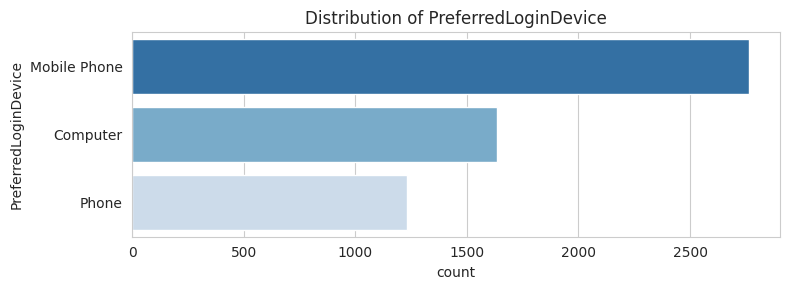

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64 \n


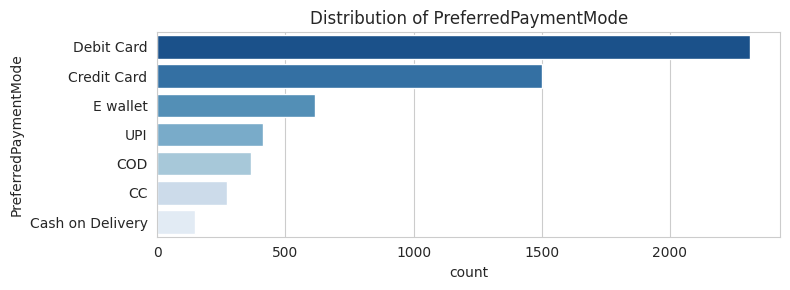

PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64 \n


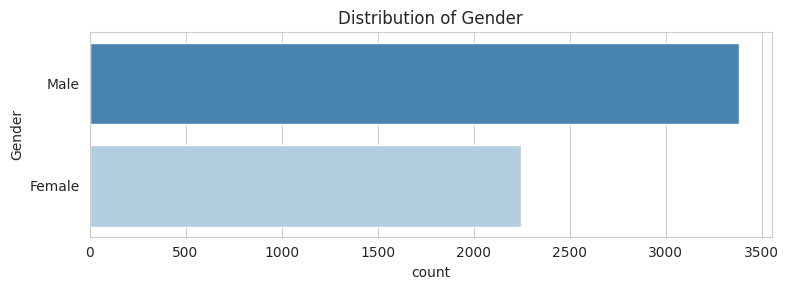

Gender
Male      3384
Female    2246
Name: count, dtype: int64 \n


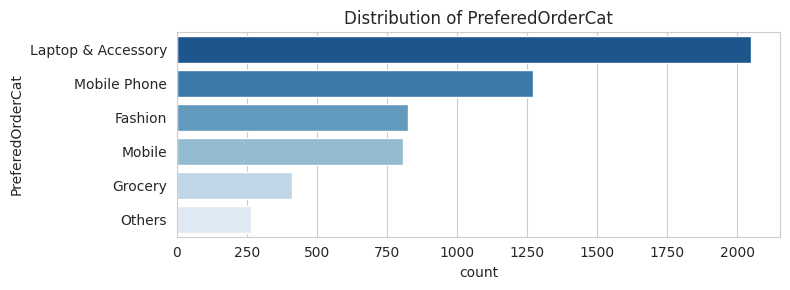

PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64 \n


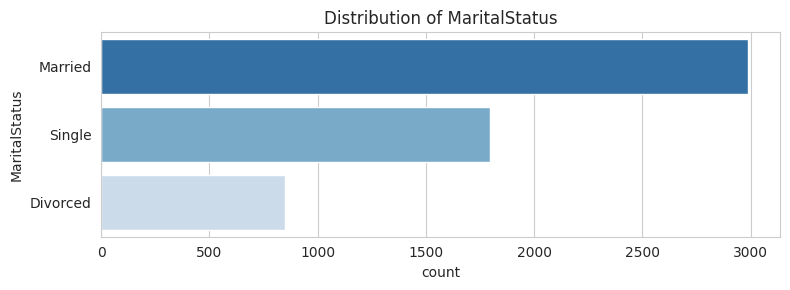

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64 \n


In [ ]:
# 4. CATEGORICAL FEATURE DISTRIBUTION
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.countplot(y=df[col], order=df[col].value_counts().index, ax=ax, palette='Blues_r')
    ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts(), "\\n")


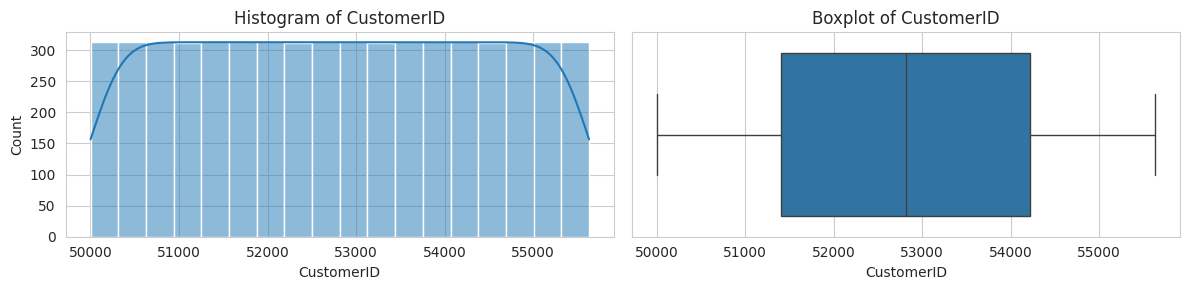

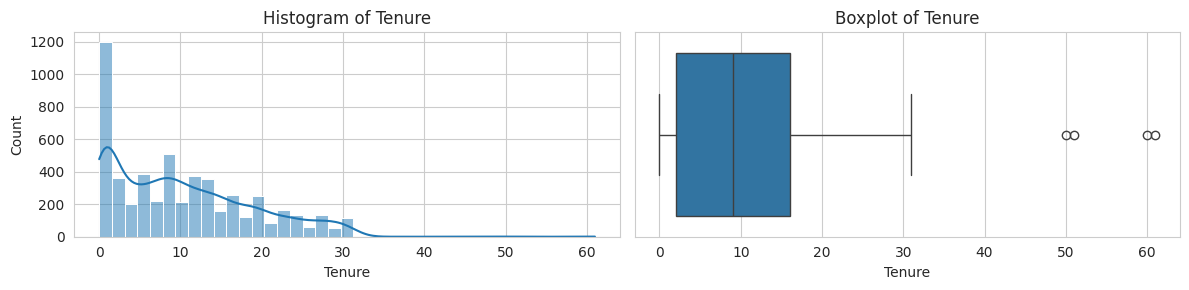

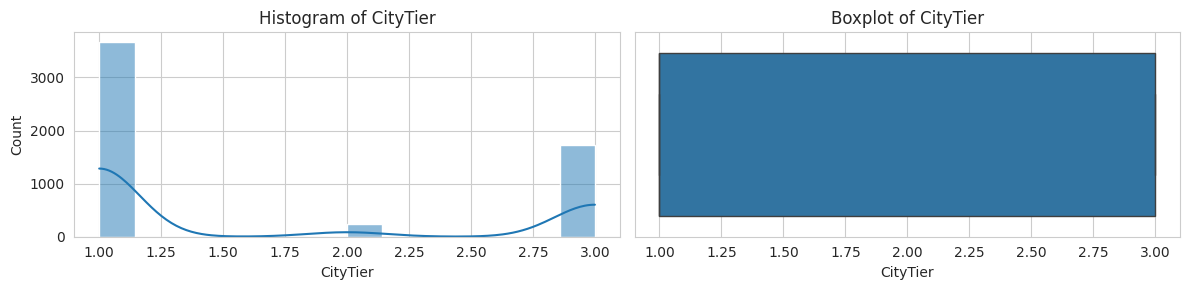

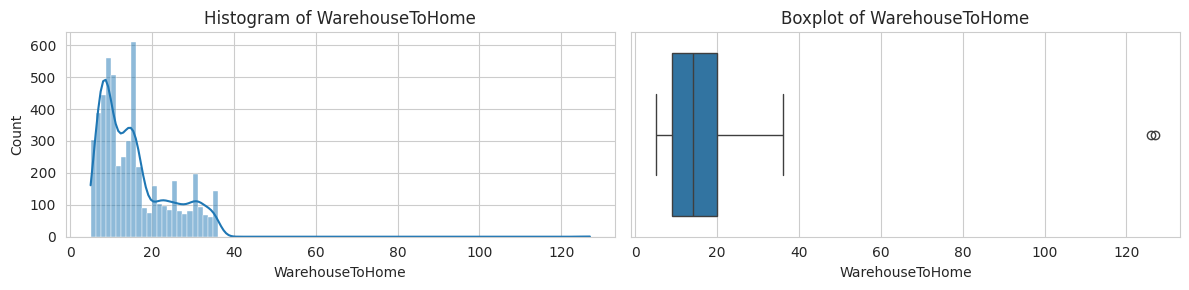

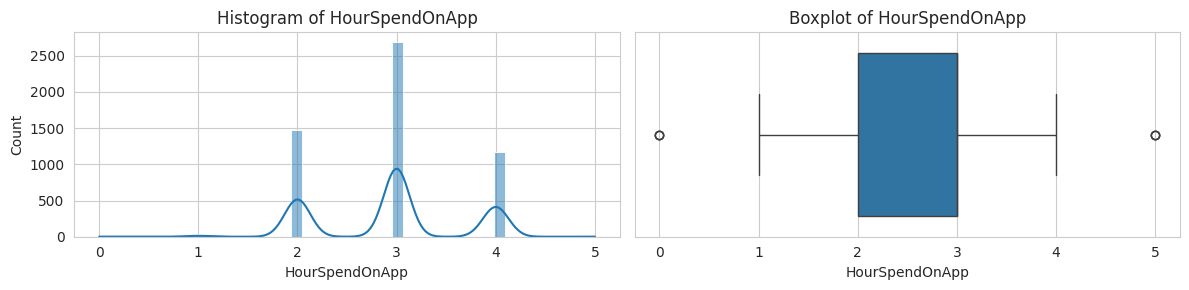

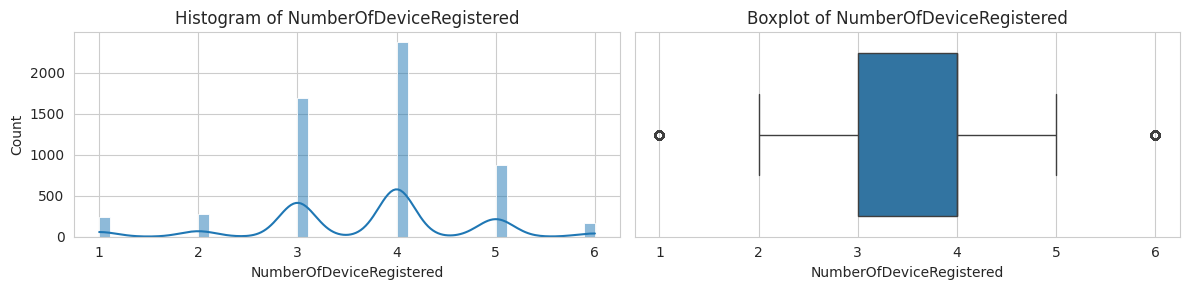

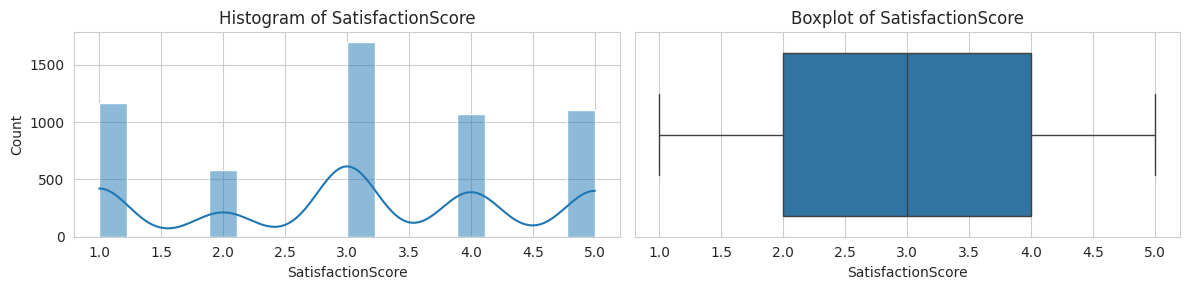

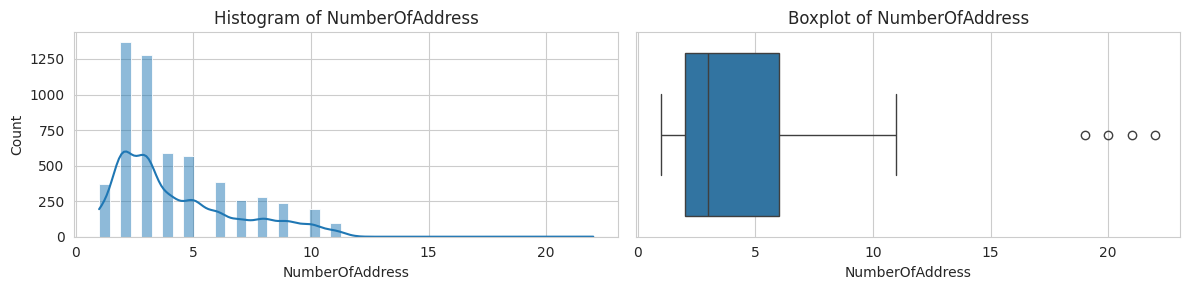

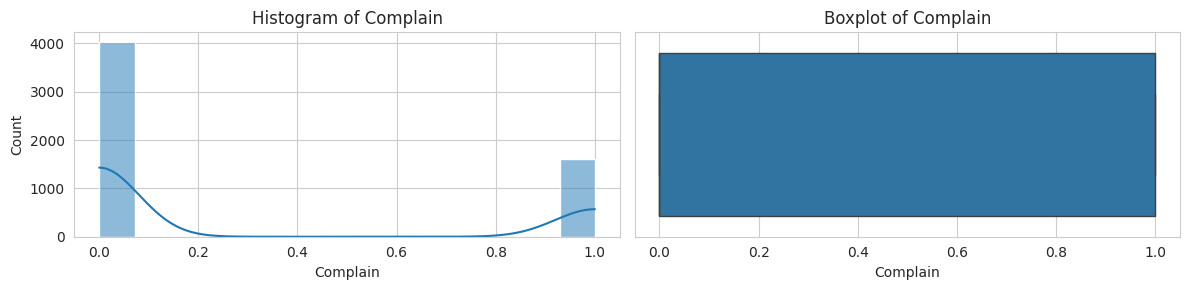

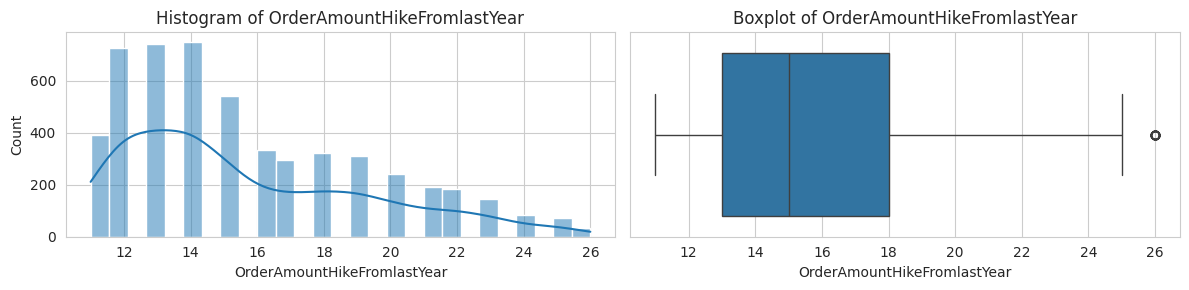

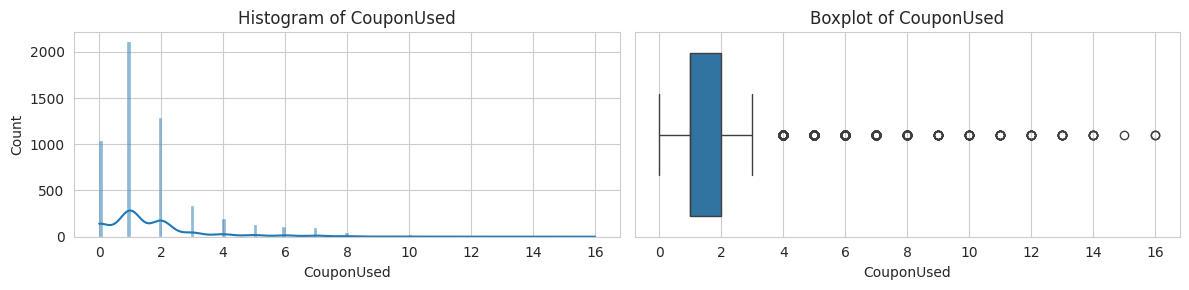

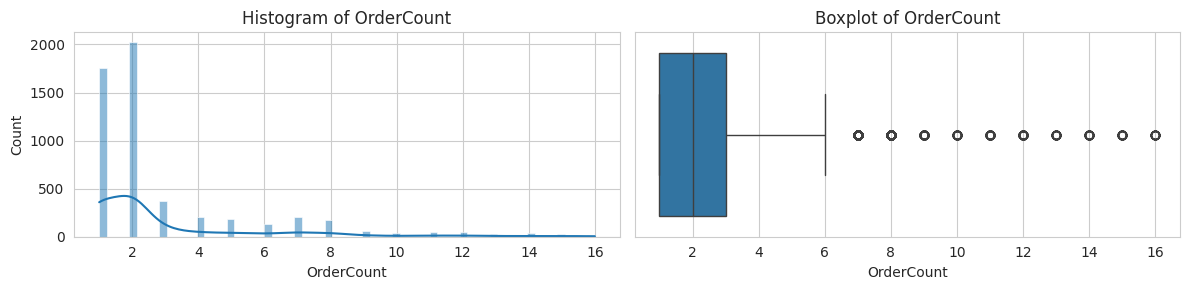

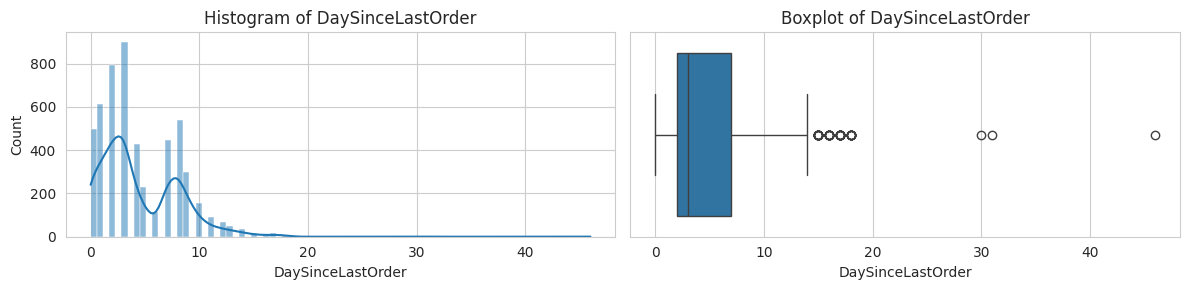

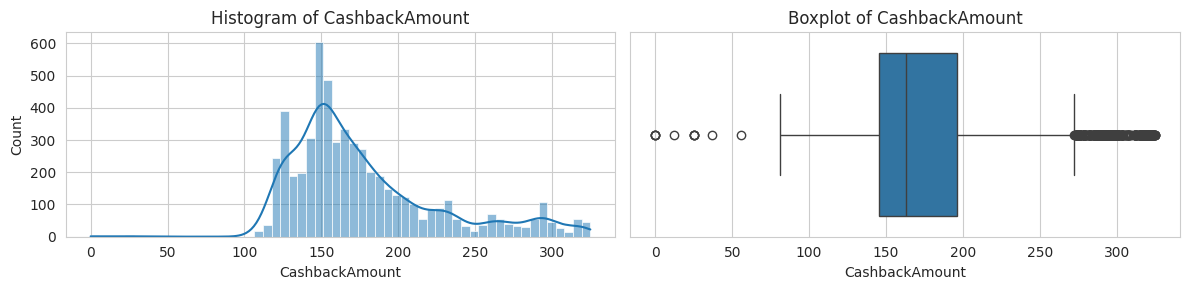

In [ ]:
# 5. NUMERICAL FEATURE DISTRIBUTION
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Histogram of {col}')
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()


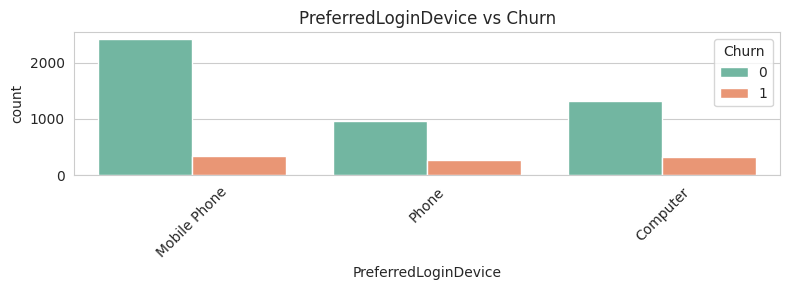

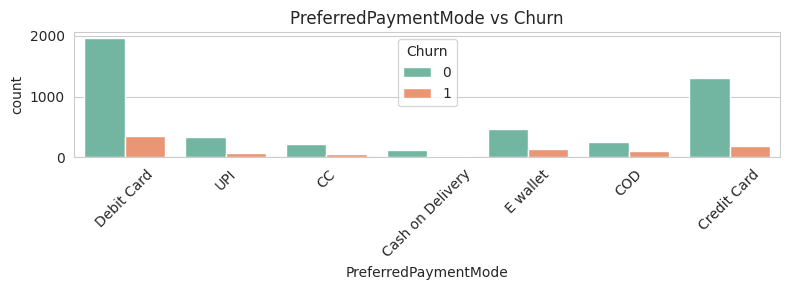

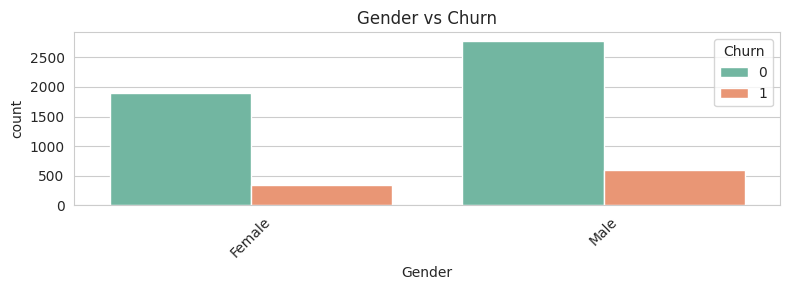

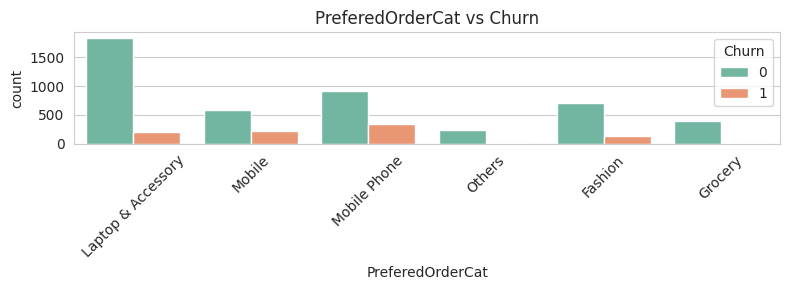

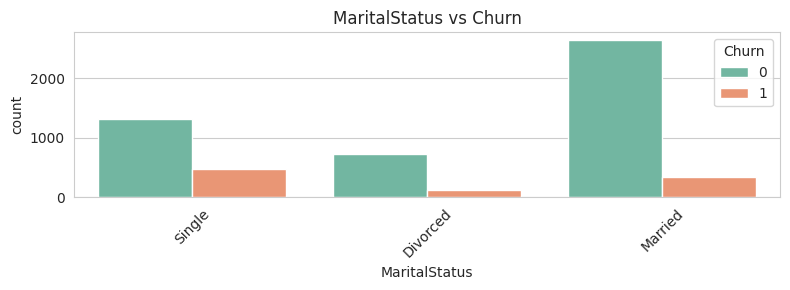

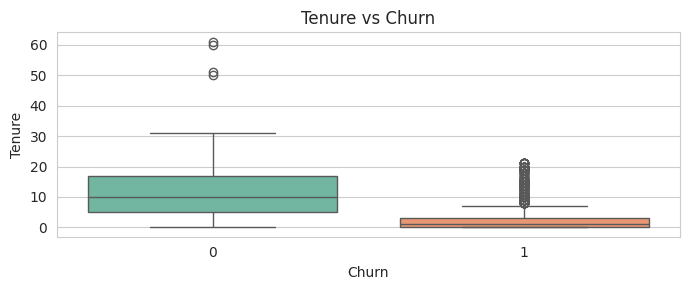

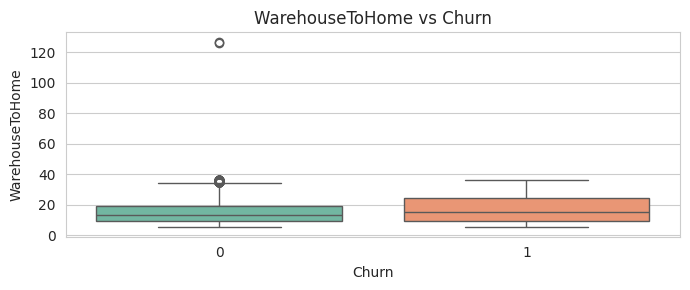

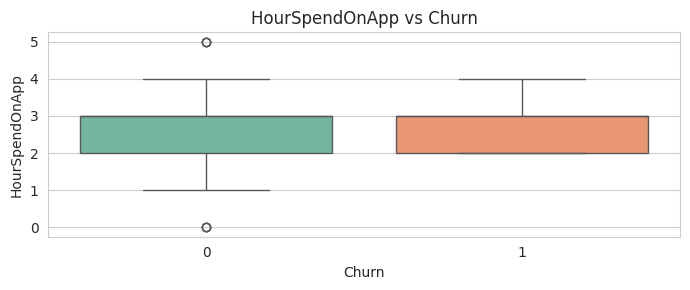

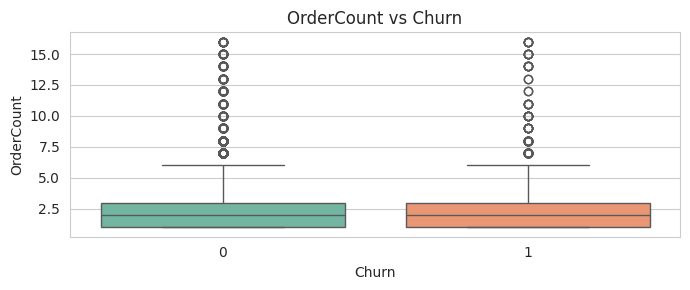

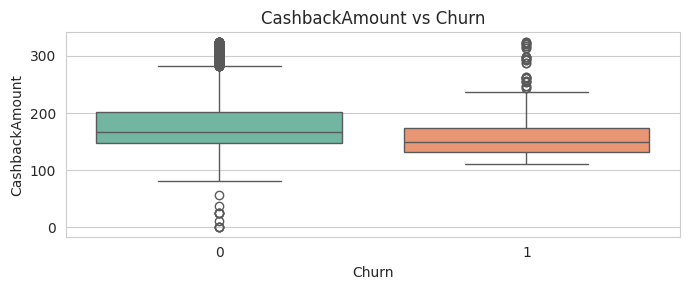

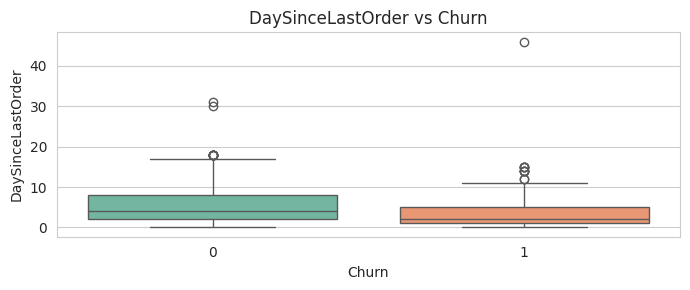

In [ ]:
# 6. BIVARIATE ANALYSIS — RELATIONSHIP WITH CHURN
# Categorical vs Churn
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Numerical vs Churn
important_num = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderCount',
                 'CashbackAmount','DaySinceLastOrder']
for col in important_num:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Churn')
    plt.tight_layout()
    plt.show()


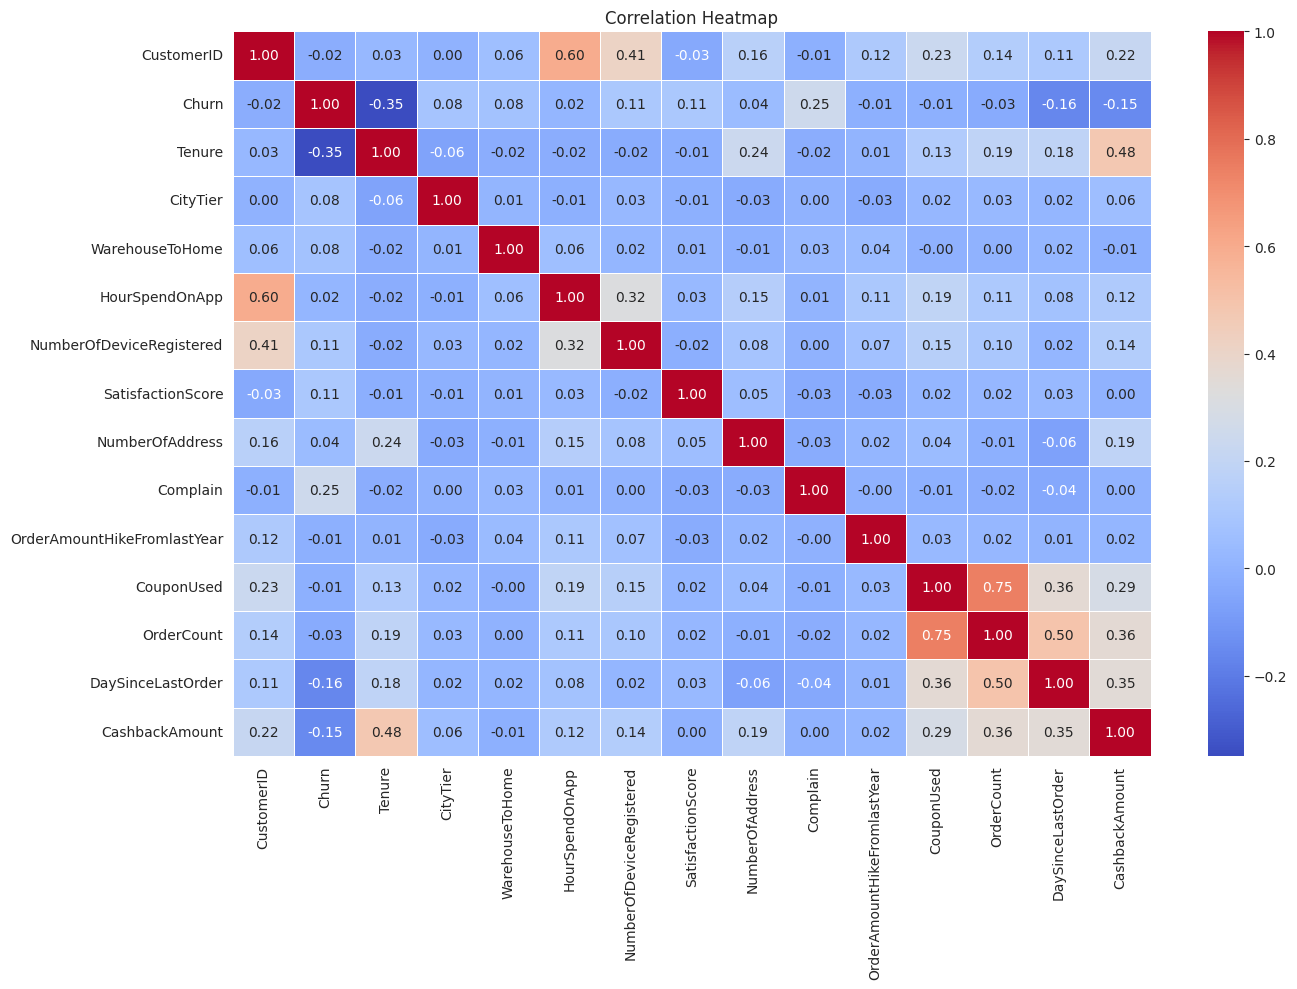

In [ ]:
# 7. CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# 🛠️ SECTION 4 — Data Preprocessing

Sub-sections:
1. Drop irrelevant columns
2. Handle missing values
3. Fix category inconsistencies
4. One-hot encoding


In [ ]:
# 1. DROP USELESS COLUMN
df.drop(['CustomerID'], axis=1, inplace=True)
print("CustomerID dropped. New shape:", df.shape)

CustomerID dropped. New shape: (5630, 19)


In [ ]:
# 2. HANDLE MISSING VALUES for i in df.columns:
cols_with_na = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder'
]
for col in cols_with_na:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum().sum(), "remaining")

Missing values after imputation:
0 remaining


In [ ]:
# 3. FIX CATEGORY INCONSISTENCIES
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'Cash on Delivery': 'COD'
})
print("PreferredPaymentMode values:", df['PreferredPaymentMode'].unique())

PreferredPaymentMode values: ['Debit Card' 'UPI' 'Credit Card' 'COD' 'E wallet']


In [ ]:
# 4. ONE-HOT ENCODING─
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (5630, 28)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,0,0,0,0,1,0,0,0,0,1
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,0,1,1,0,0,1,0,0,0,1
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,0,0,1,0,0,1,0,0,0,1
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,0,0,1,0,1,0,0,0,0,1
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,0,0,1,0,0,1,0,0,0,1


# ✂️ SECTION 5 — Train/Test Split & Feature Scaling
**Catatan desain:**
- Split dilakukan **sebelum** balancing untuk menghindari data leakage.
- `StandardScaler` di-fit **satu kali** pada `X_train` asli, kemudian digunakan
  untuk mentransformasi `X_test` dan sebagai basis setiap pipeline balancing.
- Ini memastikan konsistensi skala di seluruh eksperimen.


In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratified split — menjaga proporsi kelas di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print(f"\\nImbalance ratio (train): 1 : {sum(y_train==0)/sum(y_train==1):.2f}")

# ONE scaler, fit on raw X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform only (no leakage)
print("\\nScaler fit on X_train. X_test_scaled shape:", X_test_scaled.shape)


X_train: (3941, 27) | X_test: (1689, 27)
y_train distribution:
Churn
0    3277
1     664
Name: count, dtype: int64
\nImbalance ratio (train): 1 : 4.94
\nScaler fit on X_train. X_test_scaled shape: (1689, 27)


# ⚖️ SECTION 6 — Imbalance Handling & Class Distribution Visualization

Setiap sampler dijalankan pada `X_train_scaled` (data training yang sudah di-scale).
Scaler **tidak** dijalankan ulang per metode — menggunakan hasil dari Section 5.


In [ ]:
samplers_config = {
    'Baseline'        : None,
    'ROS'             : RandomOverSampler(random_state=42),
    'SMOTE'           : SMOTE(random_state=42),
    'BorderlineSMOTE' : BorderlineSMOTE(random_state=42),
    'ADASYN'          : ADASYN(random_state=42),
    'SMOTEENN'        : SMOTEENN(random_state=42),
}

balanced_data = {}
dist_summary  = {}

for name, sampler in samplers_config.items():
    if sampler is None:
        X_res, y_res = X_train_scaled, y_train.to_numpy()
    else:
        X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)

    balanced_data[name] = (X_res, y_res)
    n0, n1 = sum(y_res == 0), sum(y_res == 1)
    dist_summary[name] = {'Not Churn': n0, 'Churn': n1, 'Total': n0 + n1}
    print(f"{name:16s} → total: {len(y_res):6d} | "
          f"kelas 0: {n0:5d} | kelas 1: {n1:5d}")

dist_df = pd.DataFrame(dist_summary).T


Baseline         → total:   3941 | kelas 0:  3277 | kelas 1:   664
ROS              → total:   6554 | kelas 0:  3277 | kelas 1:  3277
SMOTE            → total:   6554 | kelas 0:  3277 | kelas 1:  3277
BorderlineSMOTE  → total:   6554 | kelas 0:  3277 | kelas 1:  3277
ADASYN           → total:   6640 | kelas 0:  3277 | kelas 1:  3363
SMOTEENN         → total:   5902 | kelas 0:  2657 | kelas 1:  3245


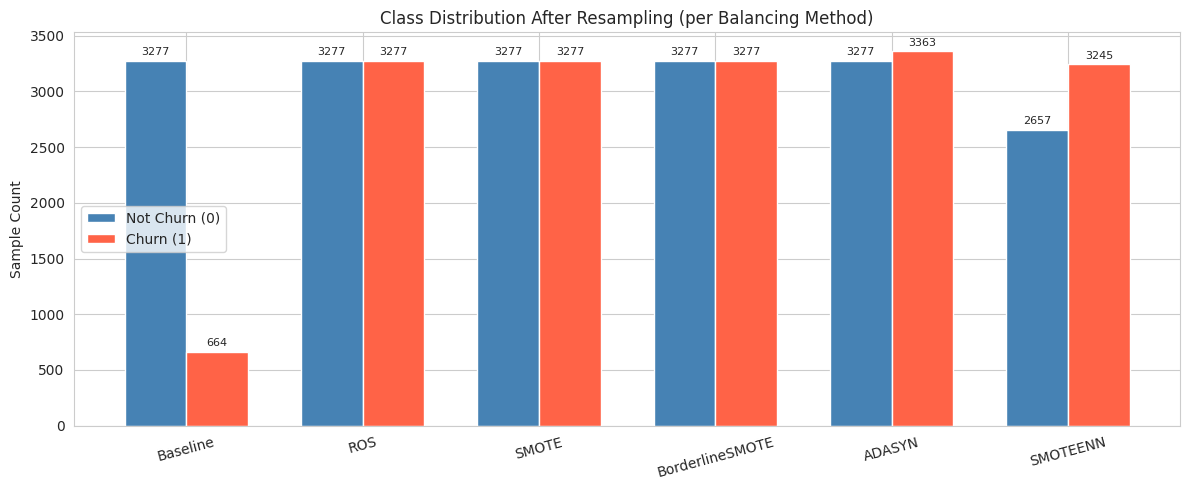

                 Not Churn  Churn  Total
Baseline              3277    664   3941
ROS                   3277   3277   6554
SMOTE                 3277   3277   6554
BorderlineSMOTE       3277   3277   6554
ADASYN                3277   3363   6640
SMOTEENN              2657   3245   5902


In [ ]:
# Visualisasi distribusi kelas setelah resampling
fig, ax = plt.subplots(figsize=(12, 5))

methods = list(dist_summary.keys())
x = np.arange(len(methods))
w = 0.35

bars0 = ax.bar(x - w/2, [dist_summary[m]['Not Churn'] for m in methods],
               width=w, label='Not Churn (0)', color='steelblue')
bars1 = ax.bar(x + w/2, [dist_summary[m]['Churn'] for m in methods],
               width=w, label='Churn (1)', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution After Resampling (per Balancing Method)')
ax.legend()

for bar in bars0:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(bar.get_height()), ha='center', va='bottom', fontsize=8)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(bar.get_height()), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(dist_df)


# 🤖 SECTION 7 — Model Definition

Semua model menggunakan **default hyperparameters** untuk menjaga fairness komparasi
antar metode balancing. Hyperparameter bukan variabel yang dikontrol dalam penelitian ini.
`random_state=42` di-set untuk reproducibility.


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost'      : XGBClassifier(random_state=42, eval_metric='logloss'),
}
print("Models defined:", list(models.keys()))


Models defined: ['Decision Tree', 'Random Forest', 'XGBoost']


# 🏋️ SECTION 8 — Training & Hold-out Test Evaluation

Setiap kombinasi (balancing method × model) dilatih dan dievaluasi pada `X_test_scaled`.

Metrik yang dikumpulkan: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**.

**Metrik utama komparasi: F1-Score dan ROC-AUC** — keduanya lebih representatif
untuk data imbalanced dibandingkan Accuracy, Precision atau Recall saja.


In [ ]:
test_results = []

for balance_name, (X_bal, y_bal) in balanced_data.items():
    for model_name, model_template in models.items():

        model = clone(model_template)
        model.fit(X_bal, y_bal)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

        test_results.append({
            'Balancing Method' : balance_name,
            'Model'            : model_name,
            'Accuracy'         : accuracy_score(y_test, y_pred),
            'Precision'        : precision_score(y_test, y_pred, zero_division=0),
            'Recall'           : recall_score(y_test, y_pred, zero_division=0),
            'F1-Score'         : f1_score(y_test, y_pred, zero_division=0),
            'ROC-AUC'          : roc_auc_score(y_test, y_prob),
            '_y_pred'          : y_pred,
            '_y_prob'          : y_prob,
            '_model'           : model,
        })

results_full_df = pd.DataFrame(test_results)
results_df = results_full_df.drop(columns=['_y_pred','_y_prob','_model'])

print("Training complete —", len(test_results), "combinations evaluated.")


Training complete — 18 combinations evaluated.


# 📊 SECTION 9 — Results & Analysis

Sub-sections:
1. Full results table (sorted by F1-Score)
2. Comparison heatmaps (per metric)
3. Confusion matrices (best model per balancing method)
4. ROC curves per model
5. Feature importance per model


In [ ]:
# 1 FULL RESULTS TABLE
print("\n" + "="*82)
print("                     FULL TEST RESULTS (sorted by F1-Score)")
print("="*82)

display_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
display_df.index += 1

# Format float columns
float_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
print(display_df[['Balancing Method','Model'] + float_cols].to_string(
    index=True, float_format='%.4f'))



                     FULL TEST RESULTS (sorted by F1-Score)
   Balancing Method          Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1          Baseline        XGBoost    0.9739     0.9615  0.8803    0.9191   0.9894
2   BorderlineSMOTE        XGBoost    0.9728     0.9375  0.8979    0.9173   0.9815
3               ROS        XGBoost    0.9716     0.9307  0.8979    0.9140   0.9868
4            ADASYN        XGBoost    0.9698     0.9331  0.8838    0.9078   0.9847
5             SMOTE        XGBoost    0.9680     0.9197  0.8873    0.9032   0.9877
6               ROS  Random Forest    0.9663     0.9349  0.8592    0.8954   0.9901
7          Baseline  Random Forest    0.9580     0.9494  0.7923    0.8637   0.9880
8             SMOTE  Random Forest    0.9562     0.9102  0.8204    0.8630   0.9830
9   BorderlineSMOTE  Random Forest    0.9550     0.9000  0.8239    0.8603   0.9842
10           ADASYN  Random Forest    0.9538     0.9055  0.8099    0.8550   0.9792
11              ROS  Decis

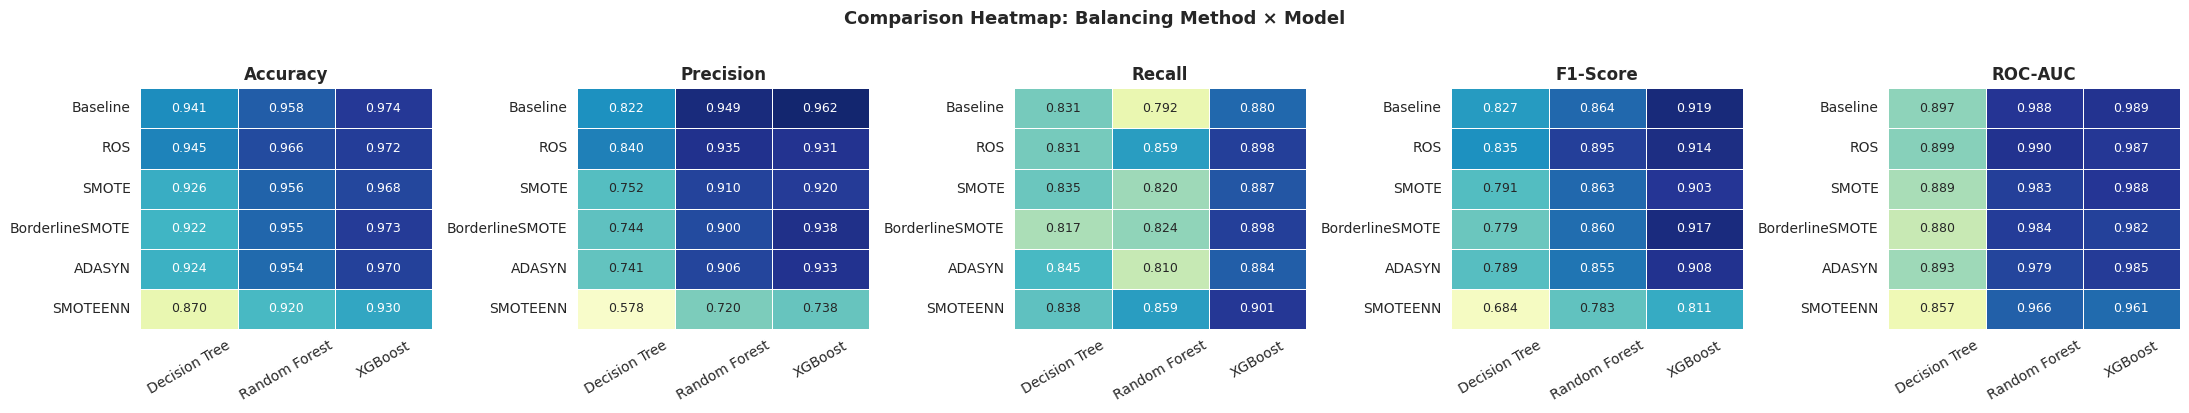

In [ ]:
# 2 COMPARISON HEATMAPS
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(22, 4))

for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index='Balancing Method', columns='Model', values=metric)
    # sort rows consistently
    pivot = pivot.reindex(['Baseline','ROS','SMOTE','BorderlineSMOTE','ADASYN','SMOTEENN'])

    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='YlGnBu',
        vmin=pivot.values.min() - 0.02,
        vmax=pivot.values.max() + 0.02,
        linewidths=0.5, ax=ax, cbar=False,
        annot_kws={'size': 9}
    )
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Comparison Heatmap: Balancing Method × Model',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


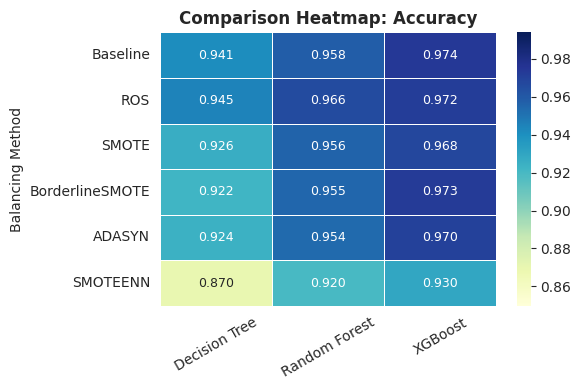

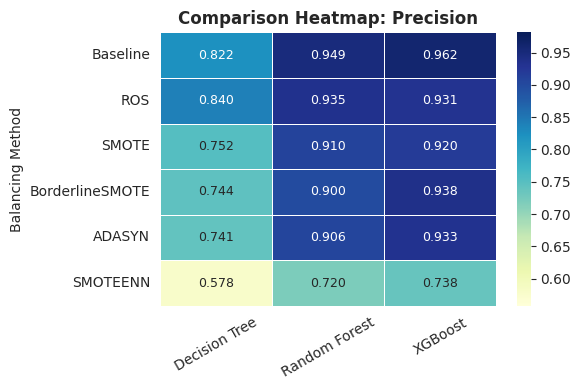

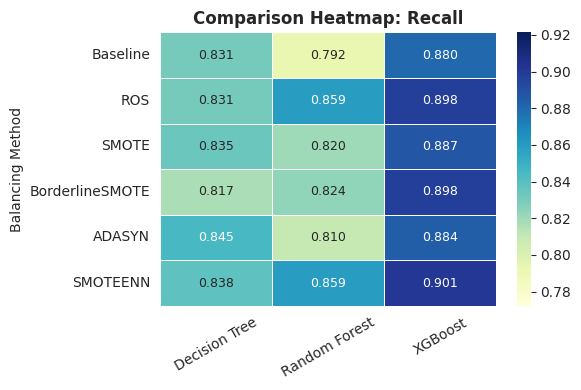

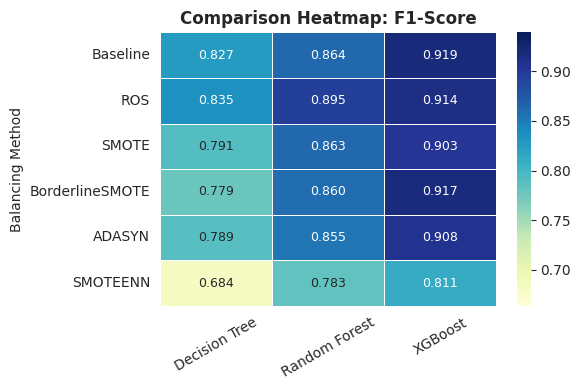

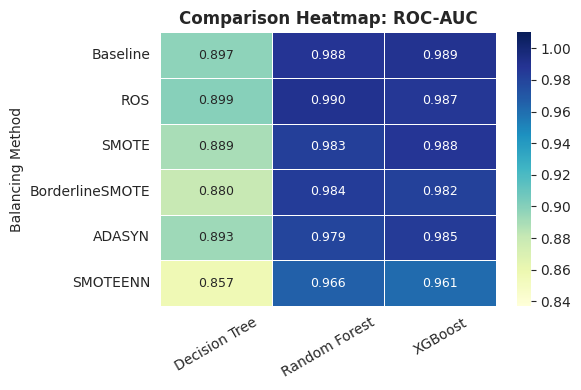

In [ ]:
# 2 COMPARISON HEATMAPS
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

row_order = ['Baseline','ROS','SMOTE','BorderlineSMOTE','ADASYN','SMOTEENN']

for metric in metrics:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4)) # Create a new figure and axes for each metric

    pivot = results_df.pivot(index='Balancing Method', columns='Model', values=metric)
    # sort rows consistently
    pivot = pivot.reindex(row_order)

    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='YlGnBu',
        vmin=pivot.values.min() - 0.02,
        vmax=pivot.values.max() + 0.02,
        linewidths=0.5, ax=ax, cbar=True, # Added cbar=True for individual plots
        annot_kws={'size': 9}
    )
    ax.set_title(f'Comparison Heatmap: {metric}', fontweight='bold') # Updated title
    ax.set_xlabel('')
    ax.set_ylabel('Balancing Method') # Added y-label for clarity
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()
    print("\n")


Confusion Matrices — Best Model per Balancing Method (by F1-Score)


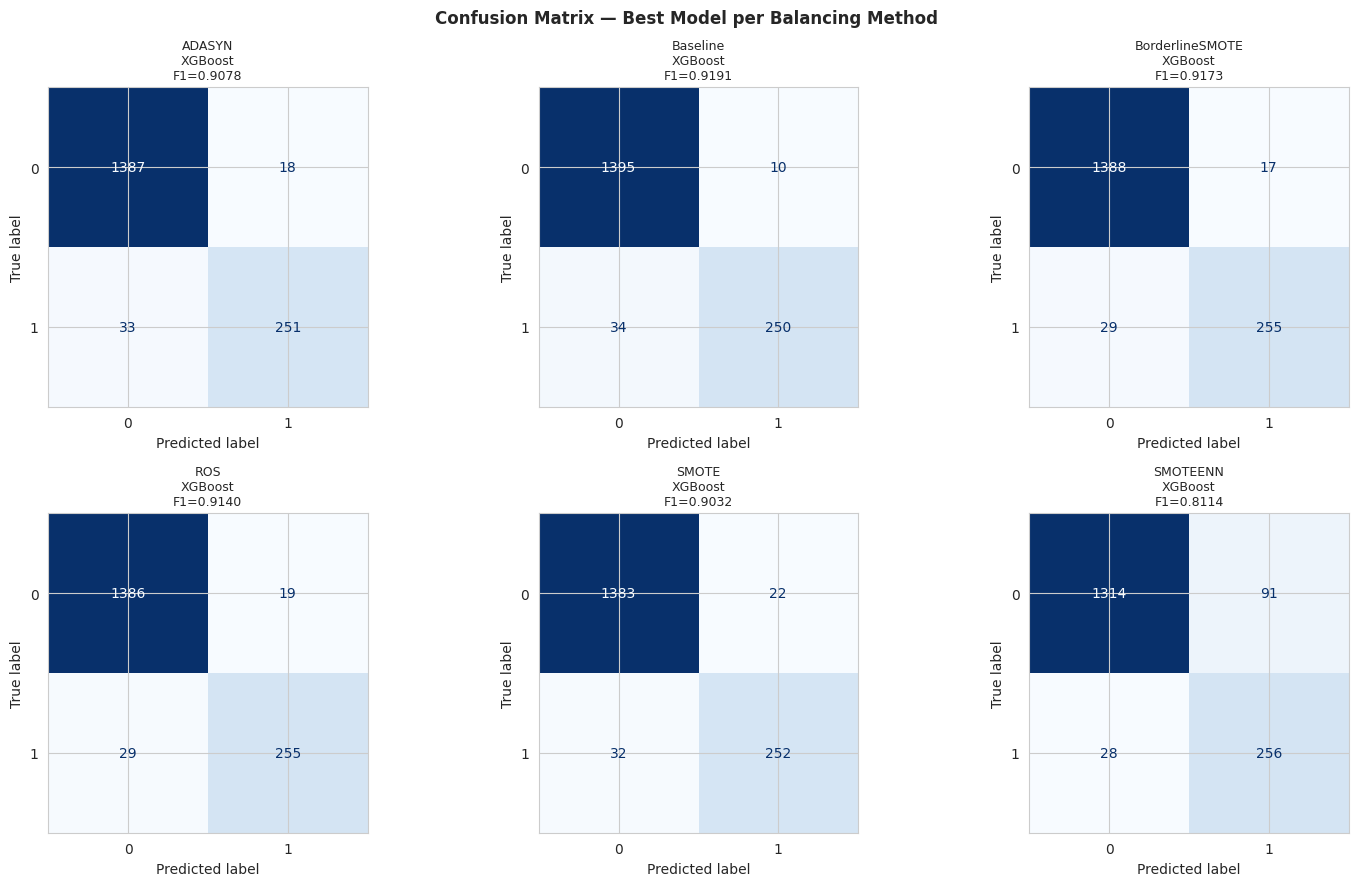

In [ ]:
# 3 CONFUSION MATRICES — Best model per balancing method (by F1)
print("Confusion Matrices — Best Model per Balancing Method (by F1-Score)")
best_per_bal = results_full_df.loc[
    results_full_df.groupby('Balancing Method')['F1-Score'].idxmax()
].reset_index(drop=True)

n = len(best_per_bal)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, row in best_per_bal.iterrows():
    ConfusionMatrixDisplay.from_predictions(
        y_test, row['_y_pred'], cmap='Blues', ax=axes[idx],
        colorbar=False
    )
    axes[idx].set_title(
        f"{row['Balancing Method']}\n{row['Model']}\nF1={row['F1-Score']:.4f}",
        fontsize=9
    )

for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix — Best Model per Balancing Method', fontweight='bold')
plt.tight_layout()
plt.show()


Confusion Matrices — Best Model per Balancing Method (by F1-Score)


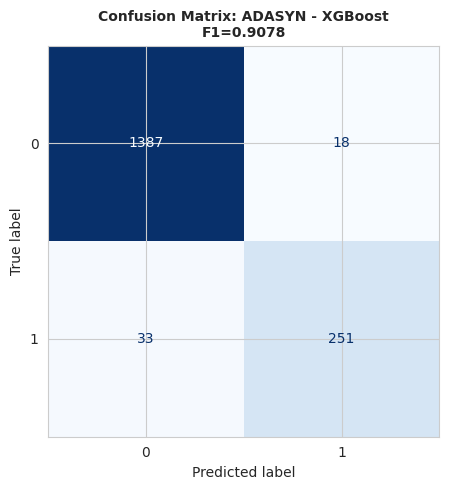

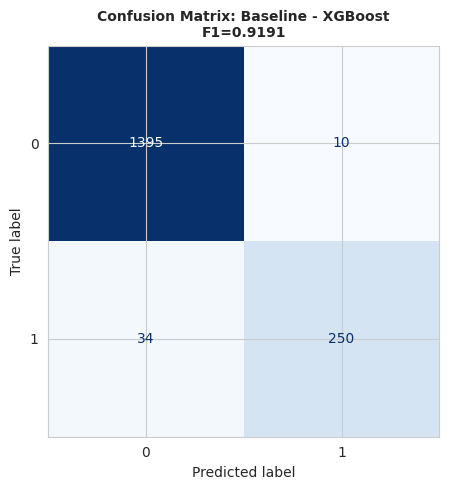

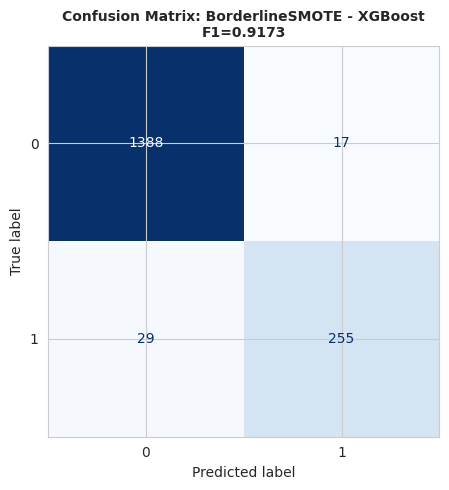

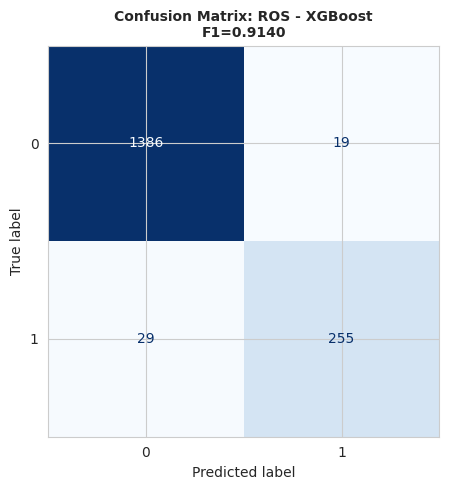

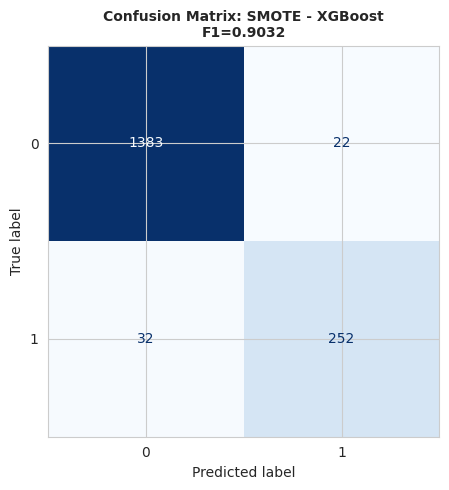

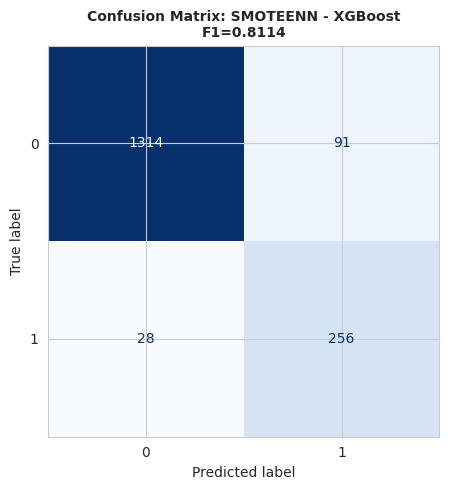

In [ ]:
# 3 CONFUSION MATRICES — Best model per balancing method (by F1)
print("Confusion Matrices — Best Model per Balancing Method (by F1-Score)")
best_per_bal = results_full_df.loc[
    results_full_df.groupby('Balancing Method')['F1-Score'].idxmax()
].reset_index(drop=True)

for idx, row in best_per_bal.iterrows():
    fig, ax = plt.subplots(1, 1, figsize=(6, 5)) # Create a new figure and axes for each confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, row['_y_pred'], cmap='Blues', ax=ax,
        colorbar=False
    )
    ax.set_title(
        f"Confusion Matrix: {row['Balancing Method']} - {row['Model']}\nF1={row['F1-Score']:.4f}",
        fontsize=10,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    print("\n")


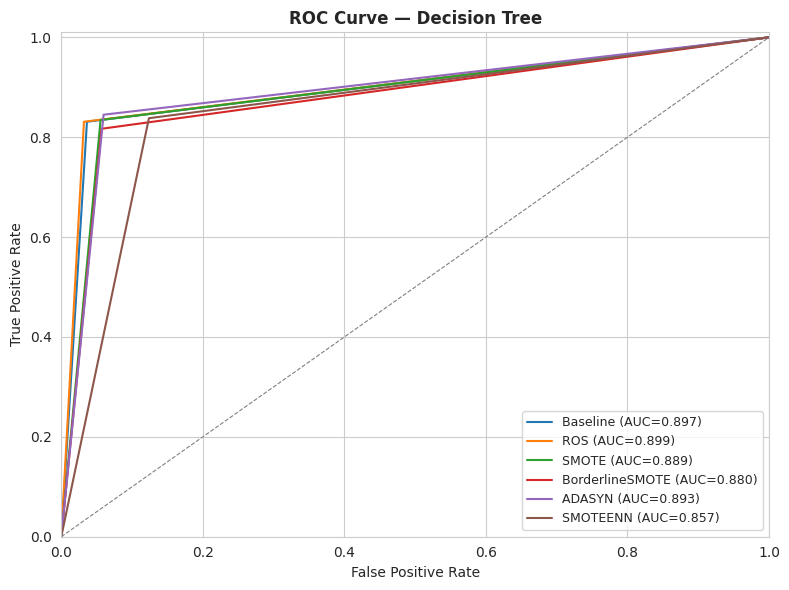

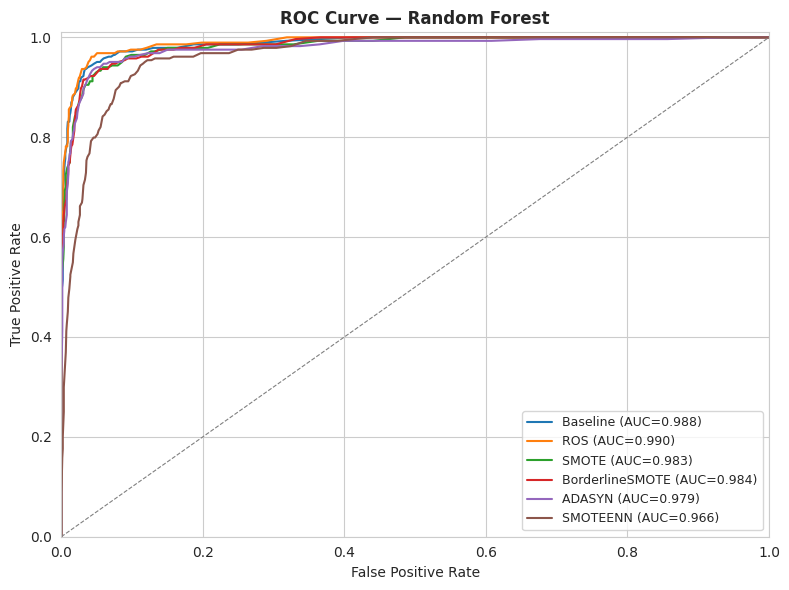

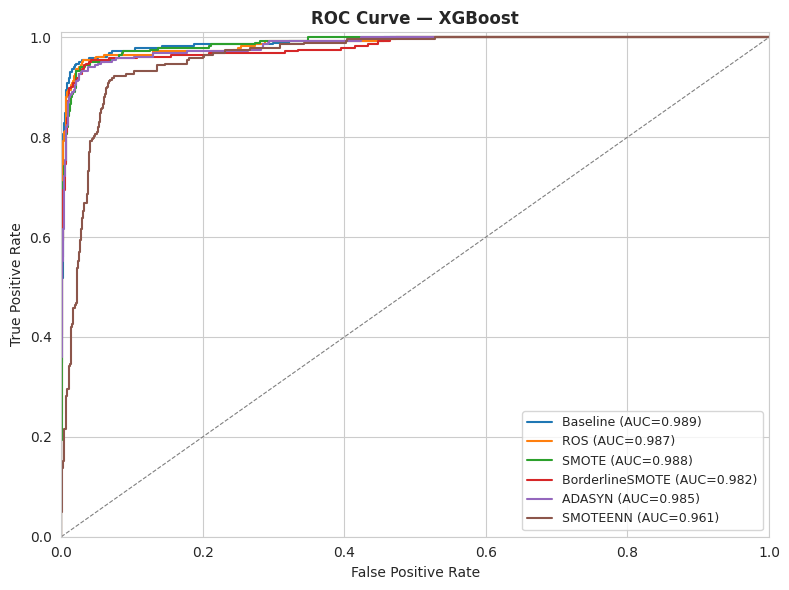

In [ ]:
# 4 ROC CURVES — Per model (all balancing methods)

for model_name in models.keys():
    fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Create a new figure and axes for each model
    subset = results_full_df[results_full_df['Model'] == model_name]
    for _, row in subset.iterrows():
        fpr, tpr, _ = roc_curve(y_test, row['_y_prob'])
        ax.plot(fpr, tpr, label=f"{row['Balancing Method']} (AUC={row['ROC-AUC']:.3f})")
    ax.plot([0,1],[0,1],'--', color='gray', linewidth=0.8)
    ax.set_title(f'ROC Curve — {model_name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.01])
    plt.tight_layout()
    plt.show()
    print("\n")

Feature Importance — Best Balancing per Model (by F1-Score)


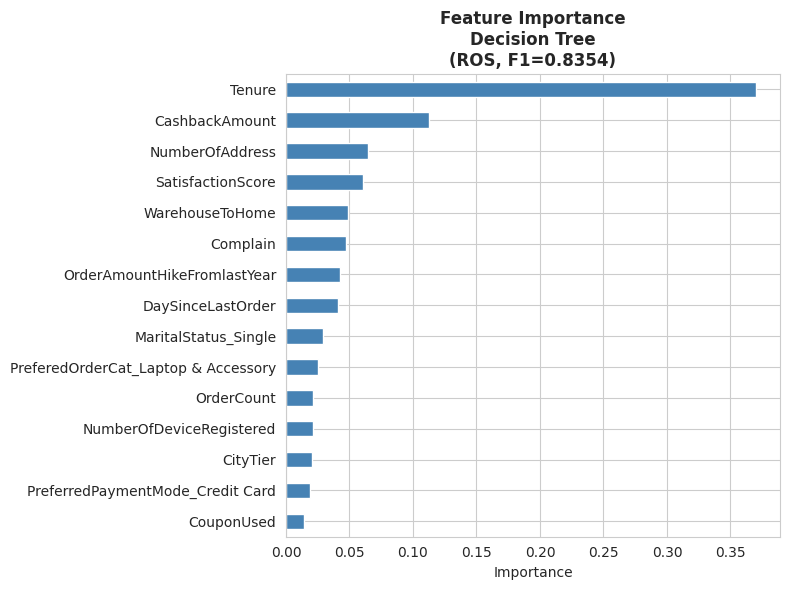

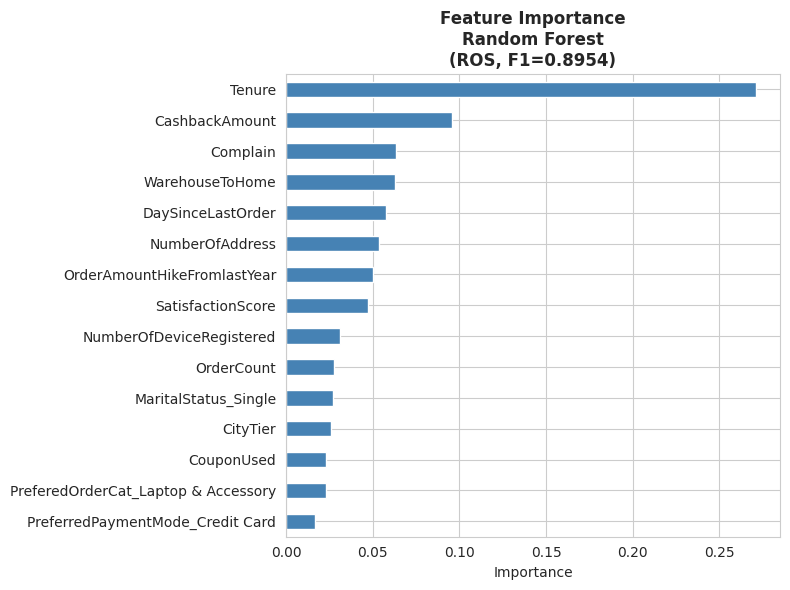

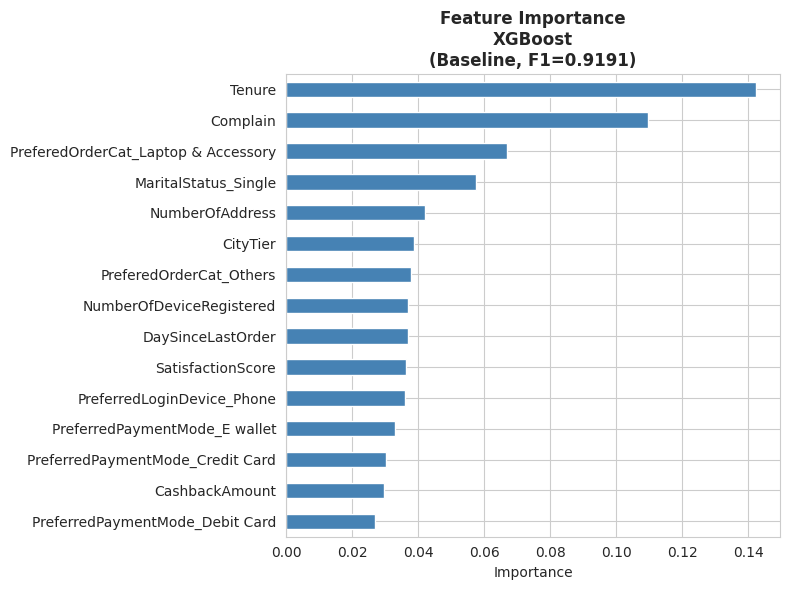




Model: Decision Tree | Balancing: ROS
Tenure                                 0.370497
CashbackAmount                         0.112747
NumberOfAddress                        0.064310
SatisfactionScore                      0.060325
WarehouseToHome                        0.048769
Complain                               0.046963
OrderAmountHikeFromlastYear            0.042244
DaySinceLastOrder                      0.041115
MaritalStatus_Single                   0.028860
PreferedOrderCat_Laptop & Accessory    0.025116

Model: Random Forest | Balancing: ROS
Tenure                         0.271330
CashbackAmount                 0.095622
Complain                       0.063554
WarehouseToHome                0.062778
DaySinceLastOrder              0.057566
NumberOfAddress                0.053514
OrderAmountHikeFromlastYear    0.050177
SatisfactionScore              0.047325
NumberOfDeviceRegistered       0.031319
OrderCount                     0.027917

Model: XGBoost | Balancing: Baseline
Te

In [ ]:
# 5 FEATURE IMPORTANCE — Per model (using best balancing per model)
print("Feature Importance — Best Balancing per Model (by F1-Score)")

best_per_model = results_full_df.loc[
    results_full_df.groupby('Model')['F1-Score'].idxmax()
].reset_index(drop=True)

for _, row in best_per_model.iterrows():
    fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Create a new figure and axes for each model
    fi = pd.Series(
        row['_model'].feature_importances_, index=X.columns
    ).nlargest(15).sort_values()

    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(
        f"Feature Importance\n{row['Model']}\n"
        f"({row['Balancing Method']}, F1={row['F1-Score']:.4f})",
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print("\n")

for _, row in best_per_model.iterrows():
    print(f"\n{'='*50}")
    print(f"Model: {row['Model']} | Balancing: {row['Balancing Method']}")
    fi = pd.Series(row['_model'].feature_importances_, index=X.columns)
    print(fi.nlargest(10).to_string())

# 🔁 SECTION 10 — Cross-Validation (5-Fold Stratified)
**Catatan metodologi penting:**
- Balancing dilakukan **di dalam setiap fold** melalui `imblearn.Pipeline`,
  bukan pada keseluruhan data sebelum CV.
- Jika balancing dilakukan di luar, data sintetis dari fold validasi akan "bocor"
  ke fold training — ini adalah **data leakage** yang mengakibatkan estimasi performa
  terlalu optimis.
- CV dijalankan pada `X` raw (belum di-scale); scaling terjadi di dalam pipeline per fold.
- Metrik: F1 (weighted), ROC-AUC, Precision (weighted), Recall (weighted).


In [ ]:
cv_samplers = {
    'Baseline'        : None,
    'ROS'             : RandomOverSampler(random_state=42),
    'SMOTE'           : SMOTE(random_state=42),
    'BorderlineSMOTE' : BorderlineSMOTE(random_state=42),
    'ADASYN'          : ADASYN(random_state=42),
    'SMOTEENN'        : SMOTEENN(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = ['f1_weighted', 'roc_auc', 'precision_weighted', 'recall_weighted']

cv_records = []

for balance_name, sampler in cv_samplers.items():
    for model_name, model_template in models.items():

        if sampler is None:
            # Baseline: only scale inside each fold
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('clf'   , clone(model_template)),
            ])
        else:
            # Balancing inside fold: scale → resample → fit
            pipe = Pipeline([
                ('scaler' , StandardScaler()),
                ('sampler', sampler),
                ('clf'    , clone(model_template)),
            ])

        scores = cross_validate(pipe, X, y, cv=cv,
                                scoring=cv_scoring, n_jobs=-1)

        cv_records.append({
            'Balancing Method' : balance_name,
            'Model'            : model_name,
            'CV_F1_mean'       : scores['test_f1_weighted'].mean(),
            'CV_F1_std'        : scores['test_f1_weighted'].std(),
            'CV_ROCAUC_mean'   : scores['test_roc_auc'].mean(),
            'CV_ROCAUC_std'    : scores['test_roc_auc'].std(),
            'CV_Precision_mean': scores['test_precision_weighted'].mean(),
            'CV_Recall_mean'   : scores['test_recall_weighted'].mean(),
            '_f1_scores'       : scores['test_f1_weighted'],
            '_auc_scores'      : scores['test_roc_auc'],
        })

        print(f"{balance_name:16s} + {model_name:15s} → "
              f"F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  |  "
              f"AUC={scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")

cv_df_full = pd.DataFrame(cv_records)
cv_df = cv_df_full.drop(columns=['_f1_scores','_auc_scores'])
print("\nCV complete.")

Baseline         + Decision Tree   → F1=0.9547 ± 0.0052  |  AUC=0.9185 ± 0.0142
Baseline         + Random Forest   → F1=0.9666 ± 0.0067  |  AUC=0.9899 ± 0.0033
Baseline         + XGBoost         → F1=0.9752 ± 0.0072  |  AUC=0.9893 ± 0.0026
ROS              + Decision Tree   → F1=0.9504 ± 0.0089  |  AUC=0.9130 ± 0.0290
ROS              + Random Forest   → F1=0.9738 ± 0.0062  |  AUC=0.9924 ± 0.0021
ROS              + XGBoost         → F1=0.9773 ± 0.0033  |  AUC=0.9872 ± 0.0037
SMOTE            + Decision Tree   → F1=0.9418 ± 0.0064  |  AUC=0.9025 ± 0.0119
SMOTE            + Random Forest   → F1=0.9589 ± 0.0085  |  AUC=0.9883 ± 0.0021
SMOTE            + XGBoost         → F1=0.9704 ± 0.0055  |  AUC=0.9858 ± 0.0027
BorderlineSMOTE  + Decision Tree   → F1=0.9389 ± 0.0065  |  AUC=0.9067 ± 0.0149
BorderlineSMOTE  + Random Forest   → F1=0.9611 ± 0.0088  |  AUC=0.9870 ± 0.0026
BorderlineSMOTE  + XGBoost         → F1=0.9742 ± 0.0052  |  AUC=0.9874 ± 0.0029
ADASYN           + Decision Tree   → F1=

In [ ]:
# CV Results Table
print("\n" + "="*123)
print("                                       CROSS-VALIDATION RESULTS (sorted by CV F1 mean)")
print("="*123)
cv_sorted = cv_df.sort_values('CV_F1_mean', ascending=False).reset_index(drop=True)
cv_sorted.index += 1
print(cv_sorted.to_string(float_format='%.4f'))



                                       CROSS-VALIDATION RESULTS (sorted by CV F1 mean)
   Balancing Method          Model  CV_F1_mean  CV_F1_std  CV_ROCAUC_mean  CV_ROCAUC_std  CV_Precision_mean  CV_Recall_mean
1               ROS        XGBoost      0.9773     0.0033          0.9872         0.0037             0.9774          0.9774
2          Baseline        XGBoost      0.9752     0.0072          0.9893         0.0026             0.9753          0.9755
3   BorderlineSMOTE        XGBoost      0.9742     0.0052          0.9874         0.0029             0.9744          0.9746
4               ROS  Random Forest      0.9738     0.0062          0.9924         0.0021             0.9739          0.9741
5            ADASYN        XGBoost      0.9726     0.0040          0.9849         0.0035             0.9727          0.9728
6             SMOTE        XGBoost      0.9704     0.0055          0.9858         0.0027             0.9704          0.9707
7          Baseline  Random Forest      0.96

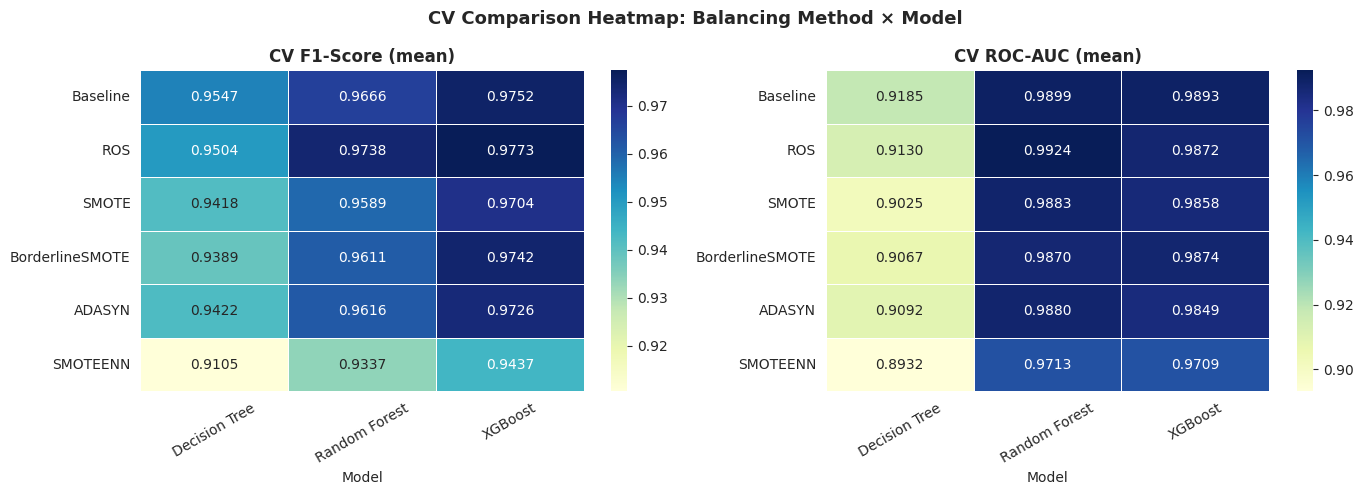

In [ ]:
# CV Comparison Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cv_metrics = [('CV_F1_mean', 'CV F1-Score (mean)'), ('CV_ROCAUC_mean', 'CV ROC-AUC (mean)')]

row_order = ['Baseline','ROS','SMOTE','BorderlineSMOTE','ADASYN','SMOTEENN']

for ax, (col, title) in zip(axes, cv_metrics):
    pivot = cv_df.pivot(index='Balancing Method', columns='Model', values=col)
    pivot = pivot.reindex(row_order)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, cbar=True, annot_kws={'size': 10})
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('CV Comparison Heatmap: Balancing Method × Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# 🏆 SECTION 11 — Summary & Conclusion

Limitasi Penelitian:

1.  Seluruh model (Decision Tree, Random Forest, XGBoost) menggunakan hyperparameter default tanpa tuning. Ini dilakukan secara sengaja agar variabel yang dibandingkan hanya metode penanganan data imbalance, bukan pengaruh tuning. Konsekuensinya, performa absolut mungkin belum optimal dan bisa meningkat jika dilakukan hyperparameter optimization (GridSearchCV/RandomizedSearchCV).

2.   Eksperimen hanya menggunakan satu dataset e-commerce, sehingga generalisasi hasil ke domain atau distribusi data yang berbeda perlu diverifikasi lebih lanjut.


Ringkasan akhir penelitian komparasi.


In [ ]:
# Hold-out test summary
print("="*82)
print("             HOLD-OUT TEST SUMMARY — Top 10 Combinations (by F1-Score)")
print("="*82)
top10 = results_df.sort_values('F1-Score', ascending=False).head(10).reset_index(drop=True)
top10.index += 1
print(top10[['Balancing Method','Model','F1-Score','ROC-AUC','Precision','Recall','Accuracy']]
      .to_string(float_format='%.4f'))

print("\n" + "="*73)
print("      CROSS-VALIDATION SUMMARY — Top 10 Combinations (by CV F1 mean)")
print("="*73)
top10_cv = cv_df.sort_values('CV_F1_mean', ascending=False).head(10).reset_index(drop=True)
top10_cv.index += 1
print(top10_cv[['Balancing Method','Model','CV_F1_mean','CV_F1_std','CV_ROCAUC_mean']]
      .to_string(float_format='%.4f'))


#  Best combination per model
print("\n\n     Best Balancing Method per Model (Hold-out F1-Score):")
print("-"*61)
best_combo = results_df.loc[results_df.groupby('Model')['F1-Score'].idxmax()]
for _, row in best_combo.iterrows():
    print(f"  {row['Model']:16s}: {row['Balancing Method']:16s} "
          f"| F1={row['F1-Score']:.4f} | AUC={row['ROC-AUC']:.4f}")

print("\n      Best Balancing Method per Model (CV F1 mean):")
print("-"*58)
best_cv_combo = cv_df.loc[cv_df.groupby('Model')['CV_F1_mean'].idxmax()]
for _, row in best_cv_combo.iterrows():
    print(f"  {row['Model']:16s}: {row['Balancing Method']:16s} "
          f"| CV F1={row['CV_F1_mean']:.4f}±{row['CV_F1_std']:.4f}")


             HOLD-OUT TEST SUMMARY — Top 10 Combinations (by F1-Score)
   Balancing Method          Model  F1-Score  ROC-AUC  Precision  Recall  Accuracy
1          Baseline        XGBoost    0.9191   0.9894     0.9615  0.8803    0.9739
2   BorderlineSMOTE        XGBoost    0.9173   0.9815     0.9375  0.8979    0.9728
3               ROS        XGBoost    0.9140   0.9868     0.9307  0.8979    0.9716
4            ADASYN        XGBoost    0.9078   0.9847     0.9331  0.8838    0.9698
5             SMOTE        XGBoost    0.9032   0.9877     0.9197  0.8873    0.9680
6               ROS  Random Forest    0.8954   0.9901     0.9349  0.8592    0.9663
7          Baseline  Random Forest    0.8637   0.9880     0.9494  0.7923    0.9580
8             SMOTE  Random Forest    0.8630   0.9830     0.9102  0.8204    0.9562
9   BorderlineSMOTE  Random Forest    0.8603   0.9842     0.9000  0.8239    0.9550
10           ADASYN  Random Forest    0.8550   0.9792     0.9055  0.8099    0.9538

      CROSS-VAL